# NODE / UDE - Remaining Useful Life (NASA C-MAPSS)

Este notebook implementa:

- Preprocesamiento de datos
- Construcción de RUL y probabilidad de falla
- NODE (Neural ODE)
- UDE (Universal Differential Equation)

In [1]:
using Pkg
Pkg.activate(".")



#solo la primera vez:
#Pkg.instantiate()

  Activating project at `c:\Users\usuario\Desktop\TP-DegradacionDeMotores\mi_entorno`


## Todas los paquetes que utilizaremos.

In [2]:
ENV["GKSwstype"] = "100"

using CSV
using DataFrames
using Statistics
using Plots

using Lux
using ComponentArrays
using Random
Random.seed!(42)

using OrdinaryDiffEq
using SciMLSensitivity

using Optimization
using OptimizationOptimisers
using Zygote
using DataInterpolations


## Carga de datos

In [3]:
dataset_path = joinpath(pwd(), "..", "CMaps", "train_FD001.txt")

train_df = CSV.read(
    dataset_path,
    DataFrame;
    delim=' ',
    ignorerepeated=true,
    header=false
)


#agregamos los nombres de la columnas ya que el dataset original venian sin ellos
rename!(
    train_df,
    vcat(
        ["unit", "cycle", "setting1", "setting2", "setting3"],
        ["s$i" for i in 1:21]
    )
)

first(train_df, 5)

Row,unit,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Float64,Float64,Float64
1,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.7,1400.6,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.419
2,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.0,23.4236
3,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.2,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
4,1,4,0.0007,0.0,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
5,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.0,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.8,8.4294,0.03,393,2388,100.0,38.9,23.4044


## Normalización de sensores y settings

In [4]:
#Normalizamos los datos de los sensores y settings para mejorar entrenamiento de redes neuronales.


sensor_cols = ["s$i" for i in 1:21]
setting_cols = ["setting1", "setting2", "setting3"]
    
for col in sensor_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end
    
for col in setting_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end

## Construcción de RUL y probabilidad de falla.

In [5]:
#Construimos el cilo de falla. En el train la falla se da en el último ciclo observado.
fail_cycles = combine(
    groupby(train_df, :unit),
    :cycle => maximum => :T_fail
)

#Obtenemos un df de la siguiente forma:
#unit    T_fail
#1       192

#Ahora mergeamos con el dataset original
train_df = leftjoin(train_df, fail_cycles, on=:unit)

#Ahora empezamos a construir la proba de falla en cada ciclo.
train_df.RUL = train_df.T_fail .- train_df.cycle

#Para construir la proba vamos a utilizar un funcion sigmoide, que sea baja           lejos de la falla y aumenta rapido cerca de la falla.
      
σ(x) = 1 / (1 + exp(-x))


#Estos hiperparametros habria que chequearlos bien...
k = 0.08
threshold = 40
    
train_df.p_fail = σ.(k .* (threshold .- train_df.RUL))

20631-element Vector{Float64}:
 5.671790689635885e-6
 6.144174602214718e-6
 6.6559014820897696e-6
 7.2102480022617275e-6
 7.810763725056275e-6
 8.461293827645233e-6
 9.16600371985333e-6
 9.929405711774312e-6
 1.0756387901826074e-5
 1.165224547006964e-5
 ⋮
 0.9282424577362486
 0.9333919644249093
 0.9381965337364114
 0.9426758241011313
 0.9468488636019362
 0.9507339939159732
 0.9543488292155562
 0.9577102281579662
 0.9608342772032357

## Ejemplo de curva de falla

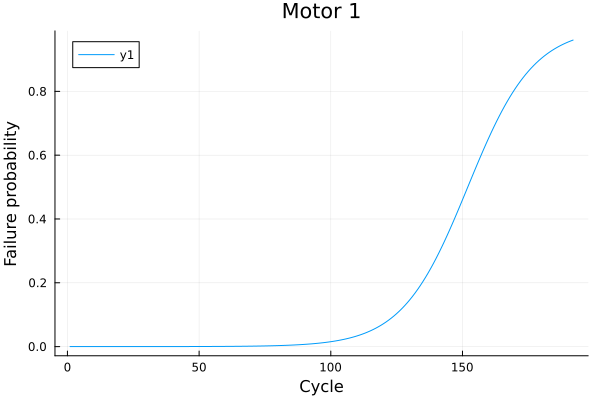

In [6]:
motor1 = filter(row -> row.unit == 1, train_df)
    
plt = plot(
    motor1.cycle,
    motor1.p_fail,
    xlabel="Cycle",
    ylabel="Failure probability",
    title="Motor 1"
)
    
plt

##  Trayectorias por motor

In [7]:
#agrupamos por unidad
grouped = groupby(train_df, :unit)
    
trajectories = []
    
for g in grouped
    X = Matrix(g[:, vcat(setting_cols, sensor_cols)])
    y = g.p_fail
    t = g.cycle
    
    push!(trajectories, (X=X, y=y, t=t))
end

##  NODE: dp/dt = NN(p, t)

NODE simple donde solo usamos los ciclos. Todavia no incorporamos sensores.

In [8]:
#elegimos una trayectoria
traj = trajectories[1]

print(trajectories)

t = Float64.(traj.t)
y = Float64.(traj.y)
    
u0 = [y[1]]
    
#generador de numeros aleatorios, sirve para inicializar los pesos de la red
rng = Random.default_rng()

#estructura de la red
nn = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#p: parametros entrenables de la red, st: estados internos
p_node, st_node = Lux.setup(rng, nn)
#esto es para que funcione bien la optimizacion
p_node = ComponentArray(p_node)

Any[(X = [-0.31597202195452145 -1.3729199290729734 NaN 0.9999757643323645 -1.7216836648226865 -0.13425192213570927 -0.925913523696359 -0.9999757643323643 0.14167989491882235 1.1211133982073023 -0.516325892386186 -0.8627924043441415 0.9999757643323643 -0.2664601377187745 0.33425373913469153 -1.0588645739680291 -0.26906451920303553 -0.603801065881639 -0.9999757643323645 -0.7816908404632746 NaN NaN 1.3484600620382499 1.1943981001535333; 0.8727007771683792 -1.0316953503320596 NaN 0.9999757643323645 -1.0617539738121262 0.2115233673416215 -0.6437102649230355 -0.9999757643323643 0.14167989491882235 0.4319197071333588 -0.7980736570341316 -0.9587943771663178 0.9999757643323643 -0.1915782821843463 1.174870847738156 -0.3636371846989997 -0.6428291567796645 -0.27584512524895916 -0.9999757643323645 -0.7816908404632746 NaN NaN 1.0165032941737064 1.2368919830975704; -1.9618266668939224 1.015652122113423 NaN 0.9999757643323645 -0.6617965853206986 -0.4131555754405577 -0.5259404010255218 -0.9999757643323

Excessive output truncated after 524289 bytes.

 -0.7995903310151717 0.04716963690970508 -1.044381041616218 0.9999757643323643 -0.004373643348315592 0.07664527036919576 0.6096811602700539 -1.2608775546798572 0.24141871607404333 -0.9999757643323645 0.5096623027963773 NaN NaN -0.2559976493069777 -0.1903482157836868; -1.1388993444242221 -1.7141445078138873 NaN 0.9999757643323645 -0.16184984970652763 -0.3789042495960974 -0.5292735103811088 -0.9999757643323643 0.14167989491882235 -0.40415132793994135 0.32891740155765065 -1.067475855832875 0.9999757643323643 -0.6408694153908625 0.13087863221453083 0.887772115976401 -1.2692649799270106 0.07344128306709452 -0.9999757643323645 -0.13601426883344866 NaN NaN -0.03469313739729522 -0.0813421682316142; 1.0555735154949795 1.015652122113423 NaN 0.9999757643323645 1.0180244463429795 0.15117579323474356 0.04957648103972403 -0.9999757643323643 0.14167989491882235 0.18335804805748504 0.4697912838848265 -0.8944911689552585 0.9999757643323643 0.1828309954877417 0.4562788032868496 0.6096811602700539 -1.166

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.18582273 0.073365726; -1.3326262 1.9626849; … ; -1.2206342 0.22496898; 1.2360227 0.50070494], bias = Float32[0.45274794, -0.109943174, 0.2535509, 0.33633876, -0.58940434, -0.5645052, -0.6811371, -0.25305128, 0.11489113, 0.6639945, -0.4025346, -0.6888659, -0.4826754, 0.3613354, 0.48929778, -0.21674016]), layer_2 = (weight = Float32[0.3199716 0.046035804 … 0.03958083 -0.19888853], bias = Float32[-0.0893096]))

Definimos la NODE

In [9]:
function node!(du, u, p, t)
    input = [u[1], t]

    du .= nn(input, p, st_node)[1]
end

node! (generic function with 1 method)

In [10]:
#todo el intervalo de tiempo
tspan = (t[1], t[end])
	
#definimos el problema de ode
prob_node = ODEProblem(node!, u0, tspan, p_node)
	
#resolvemos con solver numerico
sol = solve(prob_node, Tsit5(), saveat=t)

retcode: Success
Interpolation: 1st order linear
t: 192-element Vector{Float64}:
   1.0
   2.0
   3.0
   4.0
   5.0
   6.0
   7.0
   8.0
   9.0
  10.0
   ⋮
 184.0
 185.0
 186.0
 187.0
 188.0
 189.0
 190.0
 191.0
 192.0
u: 192-element Vector{Vector{Float64}}:
 [5.671790689635885e-6]
 [-0.6389859493328393]
 [-1.1971182814602073]
 [-1.690072756169595]
 [-2.1514591085398314]
 [-2.5924914293618455]
 [-3.0142288955066787]
 [-3.41512428090587]
 [-3.7941918771853764]
 [-4.152477724694881]
 ⋮
 [-73.60671244711838]
 [-74.01172685927285]
 [-74.41675030417355]
 [-74.82178185297677]
 [-75.22682058487337]
 [-75.63186558708865]
 [-76.03691595488252]
 [-76.44197079154928]
 [-76.84702920841788]

## Predicción sin entrenamiento

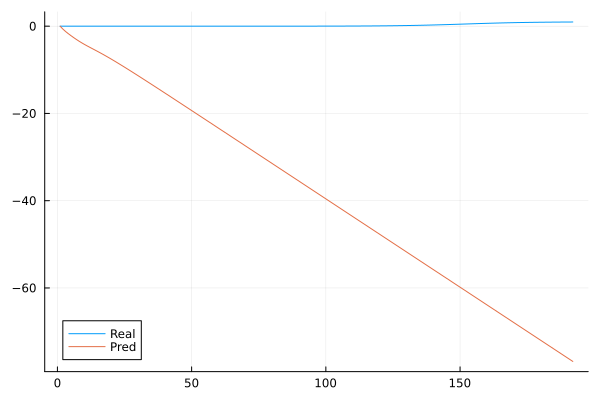

In [11]:
plt2 = plot(t, y, label="Real")
plot!(plt2, t, vec(Array(sol)), label="Pred")
	
plt2

Como se puede observar, al no haber entrenado la red no obtenemos buenos resultados.

##  Entrenamiento NODE

In [12]:
#funcion de prediccion
function predict(prob, p, t)

    _prob = remake(prob, p=p)
    
    sol = solve(
        _prob,
        Tsit5(),
        saveat=t
    )
    
    Array(sol)[1, :]
end

#funcion de perdida basica
function loss(prob, p, t, y)

    pred = predict(prob, p, t)
    
    sum(abs2, pred .- y)

end

loss (generic function with 1 method)

In [13]:
#convertimos la funcion loss en algo digerible por el optimizador. Con AutoZygote() calculamos los gradientes.
optf_node = OptimizationFunction((x, _) -> loss(prob_node,x,t,y), AutoZygote())

#Define el problema de opt. Quiero minimizar optf empezando de parametros iniciales p.
optprob_node = OptimizationProblem(optf_node, p_node)

#Resulve el problema de opt. Con Adam version de descenso por el gradiente y 0.01 el learning rate.
result_node = Optimization.solve(optprob_node, Adam(0.01), maxiters=500)
	
p_trained_node = result_node.u

#prediccion final luego de entrenar:
pred_node = predict(prob_node, p_trained_node, t)

192-element Vector{Float64}:
  5.671790689635885e-6
 -0.04486189459213208
 -0.09923701153516558
 -0.10557307590261993
 -0.08825253220874044
 -0.06583979844147159
 -0.0454655777956574
 -0.028559856620187892
 -0.01470540925328058
 -0.003102457060216534
  ⋮
  0.5138622514178848
  0.5163580730718544
  0.5190931110050987
  0.5218390301951028
  0.5244324199162117
  0.5268896469724834
  0.5294020026491865
  0.5320855595302143
  0.5347326611146708

Graficamos la sol obtenida

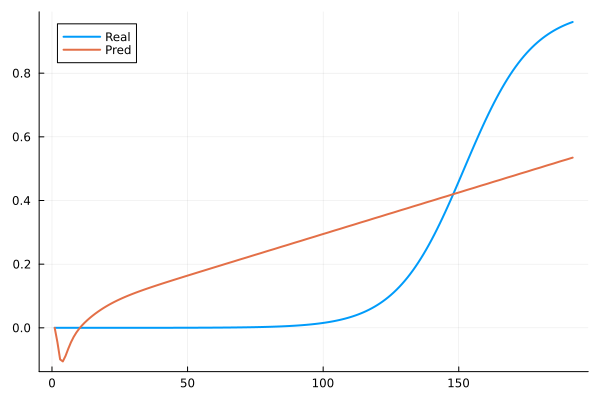

In [14]:
p1 = plot(
        t,
        y,
        label="Real",
        linewidth=2
    )
    
plot!(
    p1,
    t,
    pred_node,
    label="Pred",
    linewidth=2
)

p1

##  UDE: término físico + red neuronal

dp/dt = -αu + NN(p,t) 

In [15]:
#Definimos la red
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#parametros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)
    
α = 0.05

#definimos ude
function ude!(du, u, p, t)

    input = [u[1], t]
    du .= .-α .* u .+ nn2(input, p, st_ude)[1]

end

#definimos problema ode
prob_ude = ODEProblem(ude!, u0, tspan, p_ude)

#mismo proceso de antes
optf_ude = OptimizationFunction(
(x, _) -> loss(prob_ude,x,t,y),
AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u
pred_ude = predict(prob_ude, p_trained_ude, t)

192-element Vector{Float64}:
 5.671790689635885e-6
 0.01001693725453021
 0.014888588404793629
 0.013339684623135459
 0.012646724397608477
 0.013027048314762727
 0.01347481030924492
 0.013476376014399306
 0.013004675309415023
 0.012242592109516165
 ⋮
 0.7644591908841722
 0.7722616118269156
 0.7800457338504894
 0.787811210780998
 0.7955577844637031
 0.8032852847630239
 0.8109936295625374
 0.818682824764978
 0.8263529642922387

Graficamos la sol obtenida:

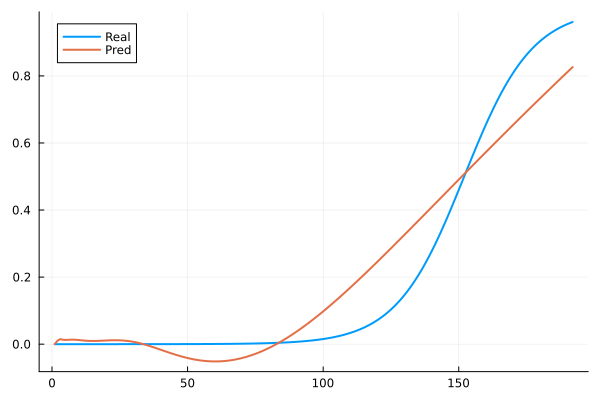

In [16]:
p2 = plot(
    t,
    y,
    label="Real",
    linewidth=2
    )
    
plot!(
    p2,
    t,
    pred_ude,
    label="Pred",
    linewidth=2
)

##  UDE: término físico + red neuronal agregando motores


In [17]:
#Ahora tengamos en cuenta mas de una trayectoria de motor.

#hago una funcion para no practicar con todas las trajs a la ves, si no tarda demasiado

n_motors = length(trajectories)


function build_train_trajs(trajectories; n_motors=nothing, shuffle=false, seed=1234)

    total_motors = length(trajectories)

    if n_motors === nothing
        selected_ids = collect(1:total_motors)
    else
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = collect(1:n)
    end


    #esto recontraponele, capaz sirve capaz no, pero como el test te da cualquier motor esto lo hace mas random
    if shuffle
        rng = Random.default_rng()
        Random.seed!(rng, seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    train_trajs = [
        (
            X = trajectories[i].X,
            t = Float64.(trajectories[i].t),
            y = Float64.(trajectories[i].y)
        )
        for i in selected_ids
    ]

    return train_trajs
end

function predict_traj(f!, p, traj)

    t = traj.t
    y = traj.y

    u0 = [y[1]]
    tspan = (t[1], t[end])

    prob = ODEProblem(f!, u0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=t,
        abstol=1e-6,
        reltol=1e-6
    )

    return Array(sol)[1, :]
end

function loss_many(f!, p, trajs)

    total_loss = 0.0
    total_points = 0

    for traj in trajs
        pred = predict_traj(f!, p, traj)
        y = traj.y

        total_loss += sum(abs2, pred .- y)
        total_points += length(y)
    end

    return total_loss / total_points
end

loss_many (generic function with 1 method)

La función de pérdida total sobre varios motores se define como:

$$
\mathcal{L}(\theta)
=
\frac{1}{\sum_{i=1}^{M} T_i}
\sum_{i=1}^{M}
\sum_{j=1}^{T_i}
\left(
\hat{y}_{i,j}(\theta) - y_{i,j}
\right)^2
$$

In [18]:
#para las pruebas vamos con 10.



# Definimos la red de la UDE
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

# Parámetros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)

# Parámetro fijo de la parte mecanística
α = 0.05




0.05

In [19]:
train_trajs = build_train_trajs(trajectories, n_motors=10)

optf_ude = OptimizationFunction(
    (x, _) -> loss_many(ude!, x, train_trajs),
    AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u

ComponentVector{Float32}(layer_1 = (weight = Float32[-1.4433072 1.5040276; -1.1167465 1.4992776; … ; 0.711315 -0.18016283; 1.1846573 -0.79772323], bias = Float32[0.26171827, 0.61702967, -0.7174178, 0.42428952, -0.019187458, -0.7265475, 0.58127385, -0.44156283, 0.10616454, -0.2125361, 0.65605277, -0.04891494, -0.23613827, -0.13894254, -0.45984954, -0.67627084]), layer_2 = (weight = Float32[-0.03210224 -0.031218512 … 0.16428986 -0.1392004], bias = Float32[0.10490558]))

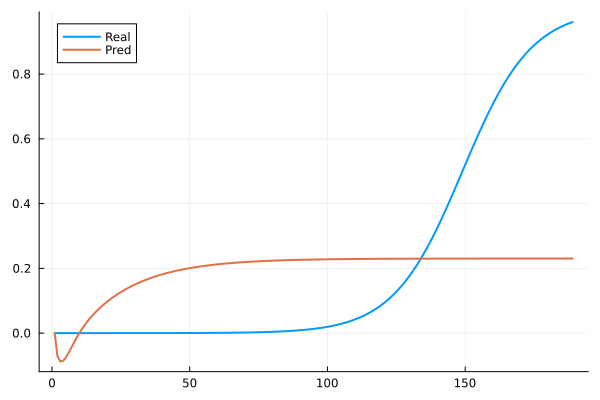

In [20]:
traj_plot = train_trajs[4]

pred_ude_n = predict_traj(ude!, p_trained_ude, traj_plot)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_n,
    label="Pred",
    linewidth=2
)

Empeora bastante... Esto puede ser ya que estoy intentando generalizar para todos los motores, sin tener cuenta los sensores. entonces, cuando veo para el caso particular 1, no calcula bien.

Si aumento cnt de motores a 30:


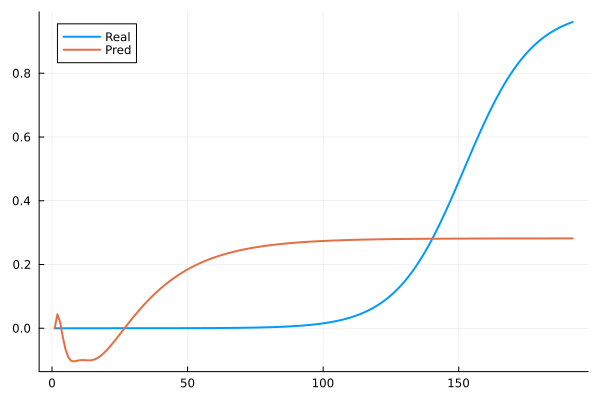

In [21]:


# Definimos la red de la UDE
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

# Parámetros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)

# Parámetro fijo de la parte mecanística
α = 0.05


train_trajs = build_train_trajs(trajectories, n_motors=30)

optf_ude = OptimizationFunction(
    (x, _) -> loss_many(ude!, x, train_trajs),
    AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u

traj_plot = train_trajs[1]

pred_ude_n = predict_traj(ude!, p_trained_ude, traj_plot)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_n,
    label="Pred",
    linewidth=2
)

##  UDE: término físico + red neuronal + sensores para 1 (un) motor (no sabes lo q tarda en correr con 10)

dp/dt = -αu + NN(p,t,sens) 

In [22]:
function build_train_trajs_sensors(trajectories; n_motors=nothing, shuffle=false,sensors=nothing, seed=67)

    total_motors = length(trajectories)

    selected_ids = collect(1:total_motors)

    if shuffle
        rng = MersenneTwister(seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    if n_motors !== nothing
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = selected_ids[1:n]
    end

    # default: usar todos los sensores
    if sensors === nothing
        sensors = 4:size(trajectories[1].X, 2)
    end

    train_trajs = []

    for i in selected_ids

        t = Float64.(trajectories[i].t)

        S = Float64.(trajectories[i].X[:, sensors])

        # un interpolador por sensor, para que no quede todo discreto y de a saltos.
        sensor_interps = [
            LinearInterpolation(S[:, j], t)
            for j in 1:size(S,2)
        ]
        #esto termina siendo como funciones para cada sensor: s_1(t), s_2(t), ....

        push!(train_trajs,
            (
                sensor_interps = sensor_interps,
                sensors_ids = sensors,                  #para no perder los sensores que utilizamos
                t = t,
                y = Float64.(trajectories[i].y)
            )
        )
    end

    return train_trajs
end

build_train_trajs_sensors (generic function with 1 method)

In [23]:
train_trajs_sensors = build_train_trajs_sensors(
    trajectories;
    n_motors=1,
    sensors = [6,7]
)
n_sensors = length(train_trajs_sensors[1].sensor_interps)

println("Cantidad de sensores usados: ", n_sensors)

input_dim = 2 + n_sensors

nn2 = Lux.Chain(
    Lux.Dense(input_dim, 8, tanh), #aumente entrada para incluir sensores
    Lux.Dense(8, 1)
)

p_ude_sensors, st_ude_sensors = Lux.setup(rng, nn2)
p_ude_sensors = ComponentArray(p_ude_sensors)

α = 0.05


function ude_sensors!(du, u, p, τ, S)

    input = [u[1]; τ; S] #esto antes estaba en Float32, pero eso rompía las cosas

    out, _ = nn2(input, p, st_ude_sensors)

    du[1] = -α * u[1] + out[1]

end


function predict_traj_sensors(p, traj)

    tvec = traj.t
    y = traj.y
    

    u0 = [y[1]]

    t0 = tvec[1]
    tf = tvec[end]
    tspan = (t0, tf)

    function f!(du, u, p, t)

        #idx = clamp(searchsortedlast(tvec, t), 1, length(tvec)) #a ver, esto es para encontrar el indice del tiempo actual en el vector de tiempos de la trayectoria porque la red usa ts intermedios (t=0.5 ponele) y ahi
                                        #no hay sensores. Entonces buscamos el indice del tiempo mas cercano que no sea mayor a t, y usamos los sensores de ese indice. es una aprox, hay q charlarlo

        
        
        #S = vec(S_traj[idx, :])

        #dejo comentado lo que estaba antes y pruebo los interpoladores

        S = [
            interp(clamp(t, t0, tf))
            for interp in traj.sensor_interps
        ]

        τ = (t - t0) / (tf - t0)

        ude_sensors!(du, u, p, τ, S)

    end

    prob = ODEProblem(f!, u0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=tvec,
        abstol=1e-6,
        reltol=1e-6,
        dtmax = 1.0
    )

    return Array(sol)[1, :]

end

predict_traj_sensors (generic function with 1 method)

In [24]:
function loss_many_sensors(p, trajs)

    total_loss = 0.0
    total_points = 0

    for traj in trajs
        pred = predict_traj_sensors(p, traj)
        y = traj.y

        total_loss += sum(abs2, pred .- y)
        total_points += length(y)
    end

    return total_loss / total_points

end

loss_many_sensors (generic function with 1 method)

In [25]:
optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors(x, train_trajs_sensors),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)

result_ude_sensors = Optimization.solve(
    optprob_ude_sensors,
    Adam(1e-3), #baje el learning rate, para que no se vuelva loco el optimizador
    maxiters=500, 
    callback = (state, loss) -> begin
        println(loss)
        false
    end
)

p_trained_ude_sensors = result_ude_sensors.u

ComponentVector{Float32}(layer_1 = (weight = Float32[-1.2298175 -0.5732174 0.8782784 -1.1226822; -1.5356649 0.30144408 0.0528993 -1.1320233; … ; -0.35019282 -1.4870645 -0.34794876 -1.074513; 0.37509575 -0.63595814 0.25346017 0.95444715], bias = Float32[0.3821464, -0.3706691, -0.14114247, -0.6799119, 0.14511918, 0.5758145, -0.0762682, 0.22622406]), layer_2 = (weight = Float32[0.5818216 0.101497486 … -0.34725618 -0.35311374], bias = Float32[0.08420571]))

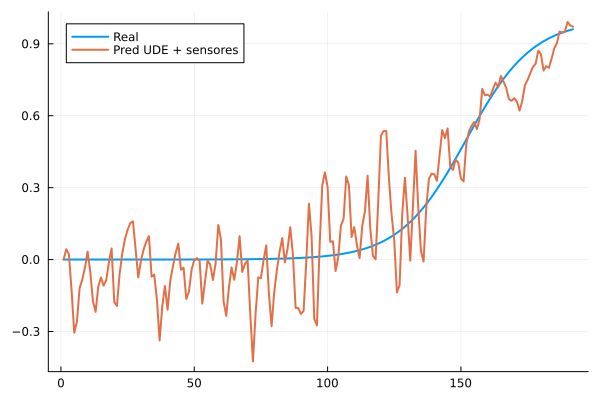

In [26]:
traj_plot = train_trajs_sensors[1]

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)

p2

## Resumen hasta acá...

Realizamos los siguientes experimentos:

+ Modelamos el problema como una NODE, solo utilizando el estado actual y el tiempo
+ Modelamos con una UDE, pero seguimos sin usar sensores
+ Entrenamos la UDE con más de una trayectoria
+ Incorporamos los sensores al modelo

Pero en el último paso nos encontramos con un problema....

Si agregamos todos los sensores al modelo nos termina quedando algo muy complejo que tarda muchísimo en correr. Entonces planteamos el siguente paso:

**Vamos a estudiar los sensores y decidir cuales son los más influyentes en el estudio de la dinámica de probabilidad de falla**

## Selección de sensores

### 1. Estudiamos varianza de los sensores

In [27]:
variances = DataFrame(
    sensor = sensor_cols,
    variance = [
        var(train_df[!, col])
        for col in sensor_cols
    ]
)

sort!(variances, :variance, rev=true)

variances

Row,sensor,variance
,String,Float64
1,s18,NaN
2,s19,NaN
3,s6,1.0
4,s2,1.0
5,s17,1.0
6,s4,1.0
7,s8,1.0
8,s9,1.0
9,s11,1.0


Recordemos que al principio del trabajo normalizamos los datos de los sensores utilizando la transformación:

$$
\frac{x - \mu}{\sigma}
$$

Por lo tanto, observamos que:

- Dos sensores presentan $Var = NaN$. Esto ocurre debido a que $\sigma = 0$, es decir, el sensor toma un valor constante para todo instante de tiempo y, por lo tanto, no aporta información útil al modelo.

- Cuatro sensores presentan una varianza muy pequeña. En consecuencia, son sensores casi constantes y decidimos excluirlos del análisis.

- Los sensores restantes presentan $Var = 1$, lo cual es esperable luego del proceso de normalización. Estos sensores son los que superan el primer filtro de selección.

In [28]:
#Definimos los sensores válidos hasta el momento:

valid_sensors = []

for col in sensor_cols

    σ_col = std(train_df[!, col])

    if !isnan(σ_col) && σ_col > 1e-8
        push!(valid_sensors, col)
    end
end

println(valid_sensors)

### 2. Correlación con RUL

La idea es identificar sensores cuyo comportamiento esté fuertemente asociado al proceso de degradación del motor.

Utilizamos el coeficiente de correlación de Pearson:

$$
\rho_{X,Y} = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}
$$

Valores cercanos a:

- $1$ indican correlación positiva fuerte
- $-1$ indican correlación negativa fuerte
- $0$ indican ausencia de correlación lineal

In [29]:
correlations = DataFrame(
    sensor = valid_sensors,
    correlation = [
        cor(train_df[!, col], train_df.RUL)
        for col in valid_sensors
    ]
)

correlations.abs_corr = abs.(correlations.correlation)

sort!(correlations, :abs_corr, rev=true)

correlations

Row,sensor,correlation,abs_corr
,Any,Float64,Float64
1,s11,-0.696228,0.696228
2,s4,-0.678948,0.678948
3,s12,0.671983,0.671983
4,s7,0.657223,0.657223
5,s15,-0.642667,0.642667
6,s21,0.635662,0.635662
7,s20,0.629428,0.629428
8,s2,-0.606484,0.606484
9,s17,-0.606154,0.606154


Nos quedaremos con el top 5 de los más correlacionados (veremos si es top 5 o menos... todo depende de cuanto tarde)

In [30]:
selected_sensors = correlations.sensor[1:5]

#y obtenemos los indices que es lo que nos sirve para pasarle a la funcion que utilizamos
"""
sensor_indices = [
    findfirst(==(s), names(train_df))
    for s in selected_sensors
]
#esto esta mal calculado, porque el indice de las columnas en train_df no es el mismo que el indice de los sensores en las trayectorias.
"""

#sensor_indices = [
#    findfirst(==(s), names(train_df)) - 2 #restamos 2 para corregir el indice
#    for s in selected_sensors
#]
#esto seria una opcion pero queda medio fragil si despues tocamos algo, para esto mejor agarro los indices de los sensores directamente del original
feature_cols = vcat(setting_cols, sensor_cols)

sensor_indices = [
    findfirst(==(s), feature_cols)
    for s in selected_sensors
]
#esto nos da los indices de los sensores seleccionados en el vector de features que usamos para entrenar las trayectorias, asi que no depende del orden de las columnas en train_df

5-element Vector{Int64}:
 14
  7
 15
 10
 18

In [31]:

for (s, idx) in zip(selected_sensors, sensor_indices)
    display( s)
    display( idx)
    display(feature_cols[idx])
    
end
#no puedo ver el output



"s11"

14

"s11"

"s4"

7

...

10

"s7"

"s15"

18

"s15"

Ahora veamos como evolucionan algunos de los sensores elegidos comparados con la probabilidad de falla:

In [32]:
function plot_sensor_vs_pfail(sensor_name; unit_id=1)

    motor = filter(row -> row.unit == unit_id, train_df)

    p = plot(
        motor.cycle,
        motor[!, sensor_name],
        xlabel="Cycle",
        ylabel=sensor_name,
        label=sensor_name,
        linewidth=2
    )

    plot!(
        p,
        motor.cycle,
        motor.p_fail,
        ylabel="p_fail",
        label="p_fail",
        linewidth=2,
        yaxis=:right
    )

    return p
end


plot_sensor_vs_pfail (generic function with 1 method)

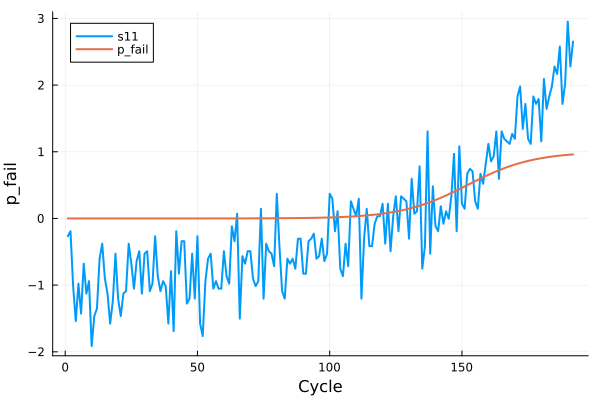

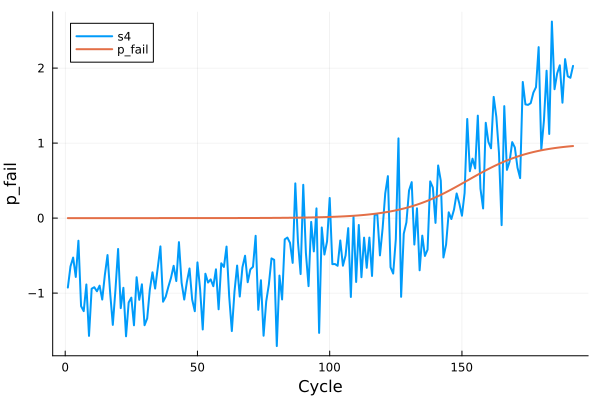

In [33]:
display(plot_sensor_vs_pfail("s11"))
display(plot_sensor_vs_pfail("s4"))

Luego de esto damos por finalizada la selección de sensores!

## UDE de antes usando los mejores sensores

En las primeras versiones del modelo utilizamos una dinámica sencilla de la forma:

$$
\frac{dp}{dt} = -\alpha p + NN(p,\tau,S(t))
$$

donde:

- $p(t)$ representa la probabilidad de falla,
- $\alpha p$ corresponde a un término físico simple,
- y $NN(\cdot)$ modela efectos no lineales aprendidos a partir de los datos.

Vamos a poner a prueba este modelo nuevamente. Pero esta vez utilizaremos los mejores sensores.

In [34]:
train_trajs_sensors = build_train_trajs_sensors(
    trajectories;
    n_motors=1,
    sensors = sensor_indices
)
n_sensors = length(train_trajs_sensors[1].sensor_interps)

println("Cantidad de sensores usados: ", n_sensors)

input_dim = 2 + n_sensors

nn2 = Lux.Chain(
    Lux.Dense(input_dim, 8, tanh), 
    Lux.Dense(8, 1)
)

p_ude_sensors, st_ude_sensors = Lux.setup(rng, nn2)
p_ude_sensors = ComponentArray(p_ude_sensors)


ComponentVector{Float32}(layer_1 = (weight = Float32[-0.07255504 1.0328946 … -0.87231374 -0.50457275; -0.8853711 -0.26409265 … -0.08173108 0.8887907; … ; 0.327073 -1.0302397 … -0.91170895 0.44349438; 0.14375076 0.5680567 … 0.114604466 -0.72184145], bias = Float32[0.22577596, 0.19985121, -0.0051052594, -0.15510212, 0.2739814, 0.32782844, 0.06507353, -0.22103818]), layer_2 = (weight = Float32[0.50426877 0.498187 … -0.44560358 -0.48255286], bias = Float32[0.12746628]))

In [35]:
optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors(x, train_trajs_sensors),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)


#agregamos early stopping...
best_loss = Inf
best_params = nothing

patience = 30
counter = 0
iter = 0
maxiters = 1000

callback = function (state, loss)

    global iter += 1

    if iter % 10 == 0
        println("Iteración: $iter / $maxiters | loss = $loss")

    end

    if loss < best_loss - 1e-6

        global best_loss = loss
        global best_params = deepcopy(state.u)

        global counter = 0

    else

        global counter += 1

    end

    if counter >= patience

        println("Early stopping activado")

        return true
    end

    return false
end


result_ude_sensors = Optimization.solve(
    optprob_ude_sensors,
    Adam(1e-3),
    maxiters=1000,
    callback=callback
)

p_trained_ude_sensors = best_params

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.14023049 0.9082998 … -0.91043174 -0.4330362; -1.0815374 -0.20664492 … -0.09728565 0.49236897; … ; 0.3878096 -0.9202362 … -0.8173782 0.36384928; 0.21329942 0.7245317 … 0.122978054 -0.7615186], bias = Float32[0.123590484, 0.16960621, 0.084488936, -0.21740717, 0.3587486, 0.46812522, 0.19844174, -0.13653965]), layer_2 = (weight = Float32[0.45576438 0.5629171 … -0.41629827 -0.38933557], bias = Float32[0.058068547]))

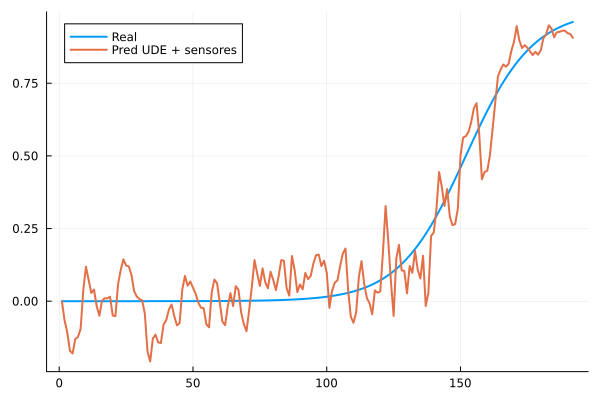

In [36]:
traj_plot = train_trajs_sensors[1]

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)

p2

In [37]:
feature_cols = vcat(setting_cols, sensor_cols)

old_indices = [
    findfirst(==(s), names(train_df))
    for s in selected_sensors
]

new_indices = [
    findfirst(==(s), feature_cols)
    for s in selected_sensors
]

comparison = DataFrame(
    selected_sensor = selected_sensors,
    old_index_from_train_df = old_indices,
    old_actual_column_in_X = [
        idx <= length(feature_cols) ? feature_cols[idx] : missing
        for idx in old_indices
    ],
    new_index_in_X = new_indices,
    new_actual_column_in_X = feature_cols[new_indices]
)

comparison

Row,selected_sensor,old_index_from_train_df,old_actual_column_in_X,new_index_in_X,new_actual_column_in_X
,Any,Int64,String,Int64,String
1,s11,16,s13,14,s11
2,s4,9,s6,7,s4
3,s12,17,s14,15,s12
4,s7,12,s9,10,s7
5,s15,20,s17,18,s15


La curva predicha se ajusta bastante mejor a la real. Sin embargo, obtenemos un resultado ruidoso. (este es el comentario antes de agreagar indexacion...) empeoraron las cosas ni idea

## Regularización

Para dejar atrás los resultados ruidosos vamos a agregar términos de regularización a nuestra función de pérdida.

In [38]:
function loss_many_sensors_reg(p, trajs)

    total_loss = 0.0
    total_points = 0

    λ = 1e-10   # peso de regularización

    for traj in trajs

        pred = predict_traj_sensors(p, traj)
        y = traj.y

        # loss de ajuste
        data_loss = sum(abs2, pred .- y)

        # regularización de suavidad
        smoothness_loss = sum(abs2, diff(pred))

        total_loss += data_loss + λ * smoothness_loss

        total_points += length(y)

    end

    return total_loss / total_points

end

loss_many_sensors_reg (generic function with 1 method)

y repetimos lo de antes...

In [39]:
nn2 = Lux.Chain(
    Lux.Dense(input_dim, 8, tanh), 
    Lux.Dense(8, 1)
)

p_ude_sensors, st_ude_sensors = Lux.setup(rng, nn2)
p_ude_sensors = ComponentArray(p_ude_sensors)

ComponentVector{Float32}(layer_1 = (weight = Float32[0.7821006 -0.85847396 … 0.3725056 -0.20494683; 0.920898 0.023408465 … 1.0521283 -0.43571386; … ; 0.50618327 -1.0771751 … 0.65821296 0.6991274; 0.67700857 -0.68266433 … 0.637994 0.2514036], bias = Float32[0.14446028, 0.076874554, -0.34424427, -0.3716125, 0.13392936, 0.08300581, -0.13053334, 0.17309964]), layer_2 = (weight = Float32[0.20434377 0.45398024 … -0.12193862 0.3164355], bias = Float32[0.17883384]))

In [40]:
optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors_reg(x, train_trajs_sensors),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)


#agregamos early stopping...
best_loss = Inf
best_params = nothing

patience = 30
counter = 0
iter = 0
maxiters = 1000




result_ude_sensors = Optimization.solve(
    optprob_ude_sensors,
    Adam(1e-3),
    maxiters=1000, #con 2000 ajusta mejor... actualizo: ahora me para el early stopping rapido nose que pasa
    callback=callback
)

p_trained_ude_sensors = best_params

#Los resultados son horribles. Lo que voy a probar despues es optimizar la f con termino de reg pero solo mirar el termino empirico para early stopping
#De esta manera puede ser que este mejorando la loss empirica pero todavia se siga ajustando la suavidad del resultado.

ComponentVector{Float32}(layer_1 = (weight = Float32[0.48440427 -1.0593411 … 0.21771838 -0.045605216; 0.6314354 -0.19280747 … 0.84909636 -0.22743683; … ; 0.9239645 -0.85716486 … 0.7863808 0.5746173; -0.041541003 -1.1320877 … 0.4549217 0.438517], bias = Float32[-0.015069655, -0.12647122, -0.5011568, -0.18101281, 0.3097367, 0.26451233, 0.0060022757, -0.020031506]), layer_2 = (weight = Float32[0.003542412 0.22986758 … -0.27753735 0.1612655], bias = Float32[0.04212011]))

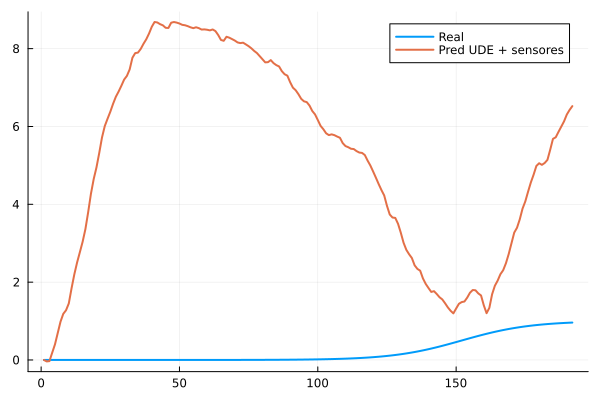

In [41]:
traj_plot = train_trajs_sensors[1]

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)

p2

Si aumentamos las iteraciones se obtienen mejores resultados, pero igualmente no estamos planteando un escenario de entrenamiento y testeo óptimo.

## Entrenamiento y Testeo adecuado

Todo muy lindo con los resutados obtenidos al seleccionar los mejores sensores. Pero estamos entrenando con una sola trayectoria y evaluando en la misma trayectoria que entrenamos. Por lo tanto, vamos a realizar lo siguiente:

+ Entrenar con x (todavía nose) trayectorias.

+ Testear con trayectorias fuera de nuestro set de entrenamiento

Antes de seguir vamos a definir una funcion para que nos devuelva set de entrenamiento y testo:

In [42]:
function build_train_test_trajs_sensors(trajectories;n_motors=nothing,test_ratio=0.2,shuffle=false,sensors=nothing,seed=67)

    total_motors = length(trajectories)

    selected_ids = collect(1:total_motors)

    # shuffle opcional (solo para definir el orden base)
    if shuffle
        rng = MersenneTwister(seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    # elegir subset de motores
    if n_motors !== nothing
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = selected_ids[1:n]
    end

    # split train/test (20% test, siguientes en la lista)
    n_test = Int(round(test_ratio * length(selected_ids)))
    test_ids = selected_ids[end - n_test + 1:end]
    train_ids = selected_ids[1:end - n_test]

    # default sensors
    if sensors === nothing
        sensors = 4:size(trajectories[1].X, 2)
    end

    # helper para construir dataset
    function build(ids)
        trajs = []

        for i in ids

            t = Float64.(trajectories[i].t)
            S = Float64.(trajectories[i].X[:, sensors])

            sensor_interps = [
                LinearInterpolation(S[:, j], t)
                for j in 1:size(S,2)
            ]

            push!(trajs,
                (
                    sensor_interps = sensor_interps,
                    sensors_ids = sensors,
                    t = t,
                    y = Float64.(trajectories[i].y)
                )
            )
        end

        return trajs
    end

    train_trajs = build(train_ids)
    test_trajs  = build(test_ids)

    return train_trajs, test_trajs
end

build_train_test_trajs_sensors (generic function with 1 method)

In [43]:
#Definimos trayectorias de entrenamiento:
train_trajs, test_trajs = build_train_test_trajs_sensors(
    trajectories;
    n_motors=10,
    test_ratio = 0.2,
    sensors = sensor_indices
)


n_sensors = length(train_trajs[1].sensor_interps)

println("Cantidad de sensores usados: ", n_sensors)

input_dim = 2 + n_sensors

nn2 = Lux.Chain(
    Lux.Dense(input_dim, 8, tanh), 
    Lux.Dense(8, 1)
)

p_ude_sensors, st_ude_sensors = Lux.setup(rng, nn2)
p_ude_sensors = ComponentArray(p_ude_sensors)

ComponentVector{Float32}(layer_1 = (weight = Float32[0.21500525 0.72969025 … 0.6515794 -0.06544449; -0.23355736 0.1003455 … -0.4904908 0.33772868; … ; 0.35908037 0.065882295 … -0.36365148 0.3302594; -0.67408526 -0.019232243 … 0.21338265 0.5485871], bias = Float32[-0.056030974, -0.2875463, -0.1330763, 0.3653886, -0.3177259, -0.2287392, -0.12774102, -0.19936685]), layer_2 = (weight = Float32[-0.40679163 -0.029365905 … -0.5044057 0.3927012], bias = Float32[0.18915029]))

In [ ]:
optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors(x, train_trajs),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)

#tengo que inicializar nuevamente los parametros del early-stopping

best_loss = Inf
best_params = nothing
patience = 30
counter = 0
iter = 0
maxiters = 500


display("Iniciando optimización...")


result_ude_sensors = @time Optimization.solve( #agrego @time para ver cuanto tarda
    optprob_ude_sensors,
    Adam(1e-3),
    maxiters=500, 
    callback=callback
)

p_trained_ude_sensors = best_params
#lo dejo anotado aca, esto tardo 17 minutos con 10 motores y 5 sensores, con early stopping.

"Iniciando optimización..."

ComponentVector{Float32}(layer_1 = (weight = Float32[0.30203125 0.5565791 … 0.5632557 0.0016570383; -0.2856499 0.3371187 … -0.45287853 0.37330878; … ; 0.49018762 -0.17683773 … -0.26485193 0.06001172; -0.73559165 0.19855836 … 0.28692144 0.48656395], bias = Float32[-0.096993014, -0.32822904, -0.09697984, 0.36873236, -0.28055745, -0.17012283, -0.12384706, -0.1310056]), layer_2 = (weight = Float32[-0.48073742 0.06904712 … -0.5727421 0.32587728], bias = Float32[0.20133068]))

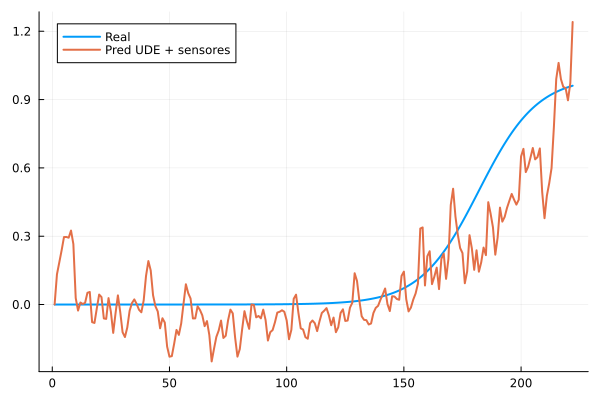

In [45]:
traj_plot = test_trajs[2]

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)


p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)

p2

## Cosas para mejorar:

+ Ver la forma de entrenar no con la trayectoria completa sino ir viendo partes de las trayectorias. Asi podemos usar mas trayectorias para entrenar y hacerlo en un tiempo razonable

+ Evaluar otro modelo. Ahora no agregamos reestricciones sobre que tiene que estar entre 0 y 1.

# TOMAR LO SIG CON PINZAS

## Evaluo modelo sigmoide, encierro la proba entre 0 y 1

Modelamos una variable latente \(z(t)\), y no directamente la probabilidad de falla. La predicción final se obtiene aplicando una sigmoide:

$$
\widehat{p}_{fail}(t)
=
\sigma(z(t))
=
\frac{1}{1+e^{-z(t)}}.
$$
La UDE con sensores queda dada por:

$$
\frac{dz}{dt}
=
-\alpha z(t)
+
NN_{\theta}
\left(
\sigma(z(t)),
\tau(t),
S(t)
\right),
$$

donde

$$
\tau(t)
=
\frac{t-t_0}{t_f-t_0}
$$

y

$$
S(t)
=
(s_1(t),\dots,s_k(t))
$$

corresponde a los sensores interpolados en el tiempo \(t\).

In [54]:
function logit(p; ϵ=1e-6)
    p_clamped = clamp(p, ϵ, 1 - ϵ)
    return log(p_clamped / (1 - p_clamped))
end


logit (generic function with 1 method)

$$
z(t_0)
=
\operatorname{logit}(p_{fail}(t_0))
=
\log\left(
\frac{p_{fail}(t_0)}
{1-p_{fail}(t_0)}
\right).
$$

In [55]:
function ude_sensors_latent!(du, z, p, τ, S)

    p_hat = σ(z[1])

    input = (vcat([p_hat, τ], S)) #pasar a float32 rompe, idk why
    #input = Float32.(vcat([p_hat, τ], S))
    out, _ = nn2(input, p, st_ude_sensors)

    du[1] = -α * z[1] + out[1]

end


ude_sensors_latent! (generic function with 1 method)

In [56]:
function predict_traj_sensors_positive(p, traj)

    tvec = traj.t
    y = traj.y

    z0 = [logit(y[1])]

    t0 = tvec[1]
    tf = tvec[end]
    tspan = (t0, tf)

    function f!(du, z, p, t)

        S = [
            interp(clamp(t, t0, tf))
            for interp in traj.sensor_interps
        ]

        τ = (t - t0) / (tf - t0)

        ude_sensors_latent!(du, z, p, τ, S)

    end

    prob = ODEProblem(f!, z0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=tvec,
        abstol=1e-6,
        reltol=1e-6,
        dtmax=1.0
    )

    z_pred = Array(sol)[1, :]

    p_pred = σ.(z_pred)

    return p_pred

end

predict_traj_sensors_positive (generic function with 1 method)

In [57]:
function loss_many_sensors_positive(p, trajs)

    total_loss = 0.0
    total_points = 0

    for traj in trajs
        pred = predict_traj_sensors_positive(p, traj)
        y = traj.y

        total_loss += sum(abs2, pred .- y)
        total_points += length(y)
    end

    return total_loss / total_points

end

loss_many_sensors_positive (generic function with 1 method)

La pérdida se calcula sobre la probabilidad transformada:

$$
\mathcal{L}(\theta)
=
\frac{1}{\sum_{i=1}^{M}T_i}
\sum_{i=1}^{M}
\sum_{j=1}^{T_i}
\left(
\sigma(z_i(t_{i,j};\theta))
-
p_{fail,i,j}
\right)^2.
$$

In [61]:
optf_ude_sensors = OptimizationFunction(
    (x, _) -> loss_many_sensors_positive(x, train_trajs),
    AutoZygote()
)

optprob_ude_sensors = OptimizationProblem(
    optf_ude_sensors,
    p_ude_sensors
)
best_loss = Inf
best_params = nothing
patience = 30
counter = 0
iter = 0
maxiters = 500


result_ude_sensors = @time Optimization.solve(
    optprob_ude_sensors,
    Adam(1e-3),
    maxiters=1000,
    callback=callback
)

p_trained_ude_sensors = best_params
#lo dejo anotado aca, esto tardo 2 minutos con 10 motores y 5 sensores, con early stopping. 

ComponentVector{Float32}(layer_1 = (weight = Float32[0.23809983 0.6074021 … 0.64812213 0.10274669; 0.6558153 0.43261078 … -0.46151876 1.2175187; … ; -0.22540186 -0.048175707 … -0.49132505 0.032131027; -0.35402232 0.23128018 … 0.21554108 0.9383407], bias = Float32[0.18617451, -0.70114845, 0.09972353, 0.9309403, -0.7002916, 0.19733569, -0.060262952, 0.063977055]), layer_2 = (weight = Float32[-0.3325525 0.3553601 … -0.48752773 0.41911668], bias = Float32[0.21713895]))

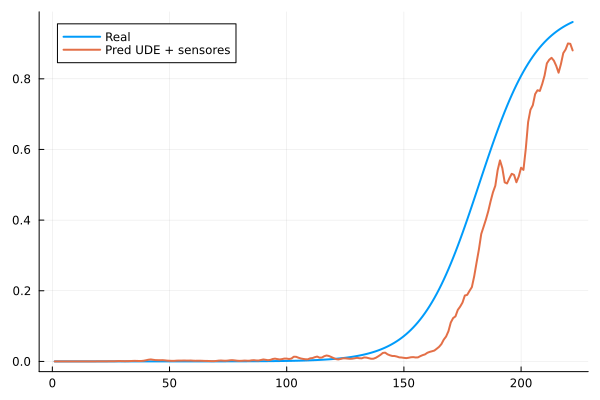

In [65]:
traj_plot = test_trajs[2]


pred_ude_sensors = predict_traj_sensors_positive(
    p_trained_ude_sensors,
    traj_plot
)

p2 = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real",
    linewidth=2
)

plot!(
    p2,
    traj_plot.t,
    pred_ude_sensors,
    label="Pred UDE + sensores",
    linewidth=2
)


# TOMAR LO anterior CON PINZAS

# Veamos si podemos agarrar ventanas de motores

## Generemos n ventanas uniformemente a lo largo de la trayectoria i, de m tamaño

In [86]:
function _even_indices(N, n) #even indices es para tomar n indices uniformemente espaciados entre 1 y N

    if n <= 0
        return Int[]
    end

    n_eff = min(n, N)

    return unique(round.(Int, range(1, stop=N, length=n_eff)))

end


function _make_window(trajs, traj_idx, start_idx, end_idx, kind) #kind es para saber si la ventana es unif o late

    traj = trajs[traj_idx]

    return (
        t = traj.t[start_idx:end_idx],
        y = traj.y[start_idx:end_idx],
        sensor_interps = traj.sensor_interps,

        #tiempos de la trayectoria completa
        #necesarios para normalizar τ y evaluar interpoladores
        full_t0 = traj.t[1],
        full_tf = traj.t[end],

        #metadata útil para debug
        traj_idx = traj_idx,
        start_idx = start_idx,
        end_idx = end_idx,
        kind = kind
    )

end


function window_prep(trajs; n_uniform=30, n_late=20, m=40, shuffle=true, seed=1234)

    rng = MersenneTwister(seed)

    # Nos quedamos solo con trayectorias que soporten ventanas de tamaño m
    valid_traj_idxs = [
        i for i in eachindex(trajs)
        if length(trajs[i].t) >= m
    ]

    if length(valid_traj_idxs) == 0
        error("No hay trayectorias con longitud >= m.")
    end

    # ============================================================
    # 1. Ventanas uniformes
    # ============================================================

    uniform_candidates = []

    for traj_idx in valid_traj_idxs

        T = length(trajs[traj_idx].t)

        for start_idx in 1:(T - m + 1)

            end_idx = start_idx + m - 1

            push!(
                uniform_candidates,
                (traj_idx = traj_idx, start_idx = start_idx, end_idx = end_idx)
            )

        end
    end

    uniform_idxs = _even_indices(length(uniform_candidates), n_uniform)

    uniform_windows = [
        _make_window(
            trajs,
            uniform_candidates[idx].traj_idx,
            uniform_candidates[idx].start_idx,
            uniform_candidates[idx].end_idx,
            :uniform
        )
        for idx in uniform_idxs
    ]

    # ============================================================
    # 2. Ventanas tardías
    # ============================================================

    #esto hay q revisarlo, lo mejor seria agarrar la parte donde la curva arranca a subir. 
    #buscar metodos para saber donde esta esa parte, porque si agarro las ultimas m muestras capaz me estoy quedando solo con la parte mas plana de la curva 
    late_candidates = []
    late_windows = []
"""
    

    for traj_idx in valid_traj_idxs

        T = length(trajs[traj_idx].t)

        start_idx = T - m + 1
        end_idx = T

        push!(
            late_candidates,
            (traj_idx = traj_idx, start_idx = start_idx, end_idx = end_idx)
        )

    end

    late_idxs = _even_indices(length(late_candidates), n_late)

    late_windows = [
        _make_window(
            trajs,
            late_candidates[idx].traj_idx,
            late_candidates[idx].start_idx,
            late_candidates[idx].end_idx,
            :late
        )
        for idx in late_idxs
    ]
"""
    # ============================================================
    # 3. Unimos ambas clases de ventanas
    # ============================================================

    windows = vcat(uniform_windows, late_windows)

    if shuffle
        windows = windows[randperm(rng, length(windows))]
    end



    # ============================================================
    # 4. Resumen de ahorro por trayectoria
    # ============================================================

    savings_rows = []

    for traj_idx in eachindex(trajs)

        full_points = length(trajs[traj_idx].t)

        traj_windows = [
            w for w in windows
            if w.traj_idx == traj_idx
        ]

        n_windows_traj = length(traj_windows)

        n_uniform_traj = count(w -> w.kind == :uniform, traj_windows)
        n_late_traj = count(w -> w.kind == :late, traj_windows)

        window_points = sum(length(w.t) for w in traj_windows)

        saved_points = full_points - window_points

        saving_pct = 100 * saved_points / full_points

        push!(
            savings_rows,
            (
                traj_idx = traj_idx,
                full_points = full_points,
                n_windows = n_windows_traj,
                n_uniform = n_uniform_traj,
                n_late = n_late_traj,
                window_points = window_points,
                saved_points = saved_points,
                saving_pct = saving_pct
            )
        )

    end

    savings_df = DataFrame(savings_rows)

    total_full_points = sum(savings_df.full_points)
    total_window_points = sum(savings_df.window_points)
    total_saved_points = total_full_points - total_window_points
    total_saving_pct = 100 * total_saved_points / total_full_points

    #display("algo",var) no funciona, hay q usar d

    display("Ventanas uniformes generadas: "); display(length(uniform_windows))
    display("Ventanas tardías generadas: "); display(length(late_windows))
    display("Ventanas totales: "); display(length(windows))
    display("Tamaño de cada ventana: "); display(m)
    display("")
    display("Puntos usando trayectorias completas: "); display(total_full_points)
    display("Puntos usando ventanas: "); display(total_window_points)
    display("Puntos ahorrados: "); display(total_saved_points)
    display("Ahorro porcentual total: "); display(round(total_saving_pct, digits=2)); display("%")

    return windows, savings_df

end


window_prep (generic function with 1 method)

In [87]:
function predict_window_sensors_positive(p, window)

    tvec = window.t
    y = window.y

    z0 = [logit(y[1])]

    # Intervalo de la ventana
    t0_window = tvec[1]
    tf_window = tvec[end]
    tspan = (t0_window, tf_window)

    # Intervalo de la trayectoria completa
    full_t0 = window.full_t0
    full_tf = window.full_tf

    function f!(du, z, p, t)

        S = [
            interp(clamp(t, full_t0, full_tf))
            for interp in window.sensor_interps
        ]

        τ = (t - full_t0) / (full_tf - full_t0)

        ude_sensors_latent!(du, z, p, τ, S)

    end

    prob = ODEProblem(f!, z0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=tvec,
        abstol=1e-6,
        reltol=1e-6,
        dtmax=1.0
    )

    z_pred = Array(sol)[1, :]

    p_pred = σ.(z_pred)

    return p_pred

end

predict_window_sensors_positive (generic function with 1 method)

In [92]:
function loss_many_windows_positive(p, windows)

    total_loss = 0.0
    total_points = 0

    for window in windows

        pred = predict_window_sensors_positive(p, window)
        y = window.y

        total_loss += sum(abs2, pred .- y)
        total_points += length(y)

    end

    return total_loss / total_points

end

loss_many_windows_positive (generic function with 1 method)

In [90]:
train_w, savings_df = window_prep(
    train_trajs;
    n_uniform=20,
    n_late=10,
    m=40,
    shuffle=true,
    seed=1234
)

train_windows = train_w
savings_df = savings_df

"Ventanas uniformes generadas: "

20

"Ventanas tardías generadas: "

0

"Ventanas totales: "

...

913

"Ahorro porcentual total: "

53.3

"%"

Row,traj_idx,full_points,n_windows,n_uniform,n_late,window_points,saved_points,saving_pct
,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Float64
1,1,192,3,3,0,120,72,37.5
2,2,287,3,3,0,120,167,58.1882
3,3,179,2,2,0,80,99,55.3073
4,4,189,2,2,0,80,109,57.672
5,5,269,3,3,0,120,149,55.3903
6,6,188,2,2,0,80,108,57.4468
7,7,259,3,3,0,120,139,53.668
8,8,150,2,2,0,80,70,46.6667


In [91]:
function predict_window_sensors_positive(p, window)

    tvec = window.t
    y = window.y

    z0 = [logit(y[1])]

    # intervalo corto de la ventana
    t0_window = tvec[1]
    tf_window = tvec[end]
    tspan = (t0_window, tf_window)

    # intervalo de la trayectoria completa
    full_t0 = window.full_t0
    full_tf = window.full_tf

    function f!(du, z, p, t)

        S = [
            interp(clamp(t, full_t0, full_tf))
            for interp in window.sensor_interps
        ]

        τ = (t - full_t0) / (full_tf - full_t0)

        ude_sensors_latent!(du, z, p, τ, S)

    end

    prob = ODEProblem(f!, z0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=tvec,
        abstol=1e-6,
        reltol=1e-6,
        dtmax=1.0
    )

    z_pred = Array(sol)[1, :]

    return σ.(z_pred)

end

predict_window_sensors_positive (generic function with 1 method)

In [ ]:
optf_ude_windows = OptimizationFunction(
    (x, _) -> loss_many_windows_positive(x, train_windows),
    AutoZygote()
)

optprob_ude_windows = OptimizationProblem(
    optf_ude_windows,
    p_ude_sensors
)

best_loss = Inf
best_params = nothing
patience = 30
counter = 0
iter = 0
maxiters = 500

result_ude_windows = @time Optimization.solve(
    optprob_ude_windows,
    Adam(1e-3),
    maxiters=maxiters,
    callback=callback
)

p_trained_ude_windows = best_params
#tardo 5 min, 10 motores, sensores ver arriba, ventanas de 40 puntos, con early stopping

ComponentVector{Float32}(layer_1 = (weight = Float32[0.10567815 0.56413054 … 0.6222513 -0.05333128; 0.4975758 0.51119363 … -0.46804422 0.3061874; … ; -0.11069089 -0.06565366 … -0.4951513 0.11767622; -0.40744278 0.21900512 … 0.21702763 0.672779], bias = Float32[0.110156216, -0.6906493, 0.15715116, 0.34084982, -0.34910193, -0.085069746, -0.14602767, -0.13938242]), layer_2 = (weight = Float32[-0.28409016 0.42768076 … -0.4952036 0.31652704], bias = Float32[0.09087451]))

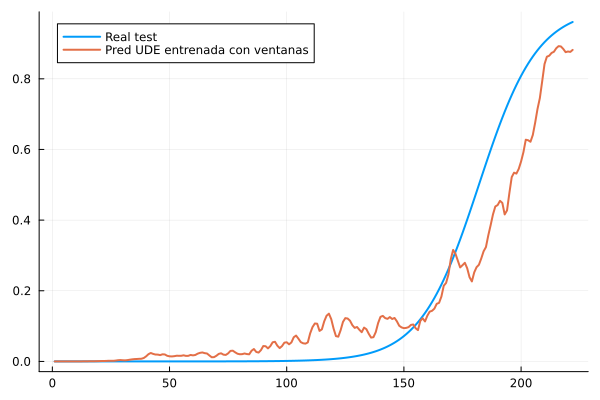

In [95]:
traj_plot = test_trajs[2]

pred_test = predict_traj_sensors_positive(
    p_trained_ude_windows,
    traj_plot
)

p = plot(
    traj_plot.t,
    traj_plot.y,
    label="Real test",
    linewidth=2
)

plot!(
    p,
    traj_plot.t,
    pred_test,
    label="Pred UDE entrenada con ventanas",
    linewidth=2
)

p